# 3. CNN-LSTM: 시간 순서를 기억하는 모델로 일반화 성능을 높일 수 있을까?

> **질문**: 앞선 노트북에서 FFT + 1D-CNN으로 파일 기반 분할 시 약 60%의 정확도를 얻었습니다.  
> LSTM은 시간 순서를 기억하는 모델인데, 이걸 추가하면 일반화 성능이 올라갈까?

## STEP 1: LSTM이란?

### 핵심 직관: "중요한 것은 오래 기억하고, 불필요한 것은 잊는다"

**LSTM (Long Short-Term Memory)**은 시계열 데이터에서 **시간 순서 정보**를 학습하는 딥러닝 구조입니다.

일반적인 비유:
- **CNN**: "지금 이 순간의 패턴"을 본다 (사진 한 장을 보는 것)
- **LSTM**: "패턴들의 시간적 흐름"을 본다 (동영상을 보는 것)

예를 들어 베어링 진동 신호에서:
- CNN은 "이 구간에 어떤 패턴이 있는가?"를 판단
- LSTM은 "이 패턴이 시간이 지나면서 어떻게 변하는가?"를 추적

LSTM은 내부에 **게이트(gate)** 구조가 있어서:
- **잊기 게이트**: 불필요한 과거 정보를 버림
- **입력 게이트**: 새로운 중요 정보를 저장
- **출력 게이트**: 현재 시점에서 필요한 정보를 출력

## STEP 2: FFT를 적용하면 시간축이 사라진다

FFT(Fast Fourier Transform)는 **시간 도메인 → 주파수 도메인** 변환입니다.

변환 후에는:
- ✅ "어떤 주파수가 얼마나 강한가" → 남아있음
- ❌ "언제 그 주파수가 나타났는가" → 사라짐

따라서 **LSTM을 쓰려면 FFT를 적용하지 않은 raw 시계열 데이터를 사용해야** 합니다.

```
┌─────────────────────────────────────────────────────┐
│  경로 A: FFT 적용                                    │
│  원본 시계열 → FFT → 주파수 스펙트럼 (시간축 없음)      │
│  → LSTM 무의미 (순서 정보가 없으므로)                  │
│  → 1D-CNN만 사용 (이전 노트북의 방식)                  │
├─────────────────────────────────────────────────────┤
│  경로 B: FFT 미적용                                  │
│  원본 시계열 → 그대로 사용 (시간축 유지)                │
│  → LSTM 활용 가능 (순서 정보 학습)                    │
│  → CNN-LSTM 조합 가능                               │
└─────────────────────────────────────────────────────┘
```

이번 노트북에서는 **경로 B**를 선택하여 CNN-LSTM 모델을 실험합니다.

## STEP 3: 데이터 준비 (Raw 시계열, FFT 없음)

이전 노트북 2와 동일한 **파일 기반 분할**을 사용합니다:
- **학습 데이터**: 007mil + 014mil 파일들
- **테스트 데이터**: 021mil 파일들
- **Normal 파일**: 시간 순서대로 앞 70%는 학습, 뒤 30%는 테스트

차이점: FFT를 적용하지 않고, raw 시계열 데이터를 그대로 사용합니다.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io
import re
import os
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# 한글 폰트 설정
import platform
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 재현성을 위한 시드 설정
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# 디바이스 설정
if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f"사용 디바이스: {device}")

사용 디바이스: mps


In [2]:
# .mat 파일에서 DE(Drive End) 신호를 읽는 함수
def get_de_signal(filepath):
    """mat 파일에서 Drive End 가속도계 신호를 추출"""
    mat = scipy.io.loadmat(filepath)
    # 파일명에서 숫자 추출하여 키 생성
    file_number = re.search(r'_(\d+)\.mat$', filepath).group(1)
    key = f'X{file_number}_DE_time'
    return mat[key].flatten()

# 슬라이딩 윈도우로 세그먼트 생성 (FFT 없이 raw 시계열 그대로)
def create_segments_raw(signal, window_size=2048, step=1024):
    """raw 시계열 신호를 슬라이딩 윈도우로 분할 (FFT 적용 안 함)"""
    segments = []
    for start in range(0, len(signal) - window_size + 1, step):
        segment = signal[start:start + window_size]
        segments.append(segment)
    return np.array(segments)

# 데이터셋 경로
dataset_path = 'dataset/'

# 파일 정의: (파일명, 라벨, 용도)
# 라벨: 0=Normal, 1=Inner Race, 2=Outer Race, 3=Ball
files_info = {
    'train': [
        (f'{dataset_path}IR007_1_110.mat', 1),
        (f'{dataset_path}IR014_1_175.mat', 1),
        (f'{dataset_path}OR007_6_1_136.mat', 2),
        (f'{dataset_path}OR014_6_1_202.mat', 2),
        (f'{dataset_path}B007_1_123.mat', 3),
        (f'{dataset_path}B014_1_190.mat', 3),
    ],
    'test': [
        (f'{dataset_path}IR021_1_214.mat', 1),
        (f'{dataset_path}OR021_6_1_239.mat', 2),
        (f'{dataset_path}B021_1_227.mat', 3),
    ]
}

# Normal 파일: 시간 기준 70/30 분할
normal_file = f'{dataset_path}Time_Normal_1_098.mat'

window_size = 2048
step = 1024

In [3]:
# 학습/테스트 데이터 생성
X_train_list, y_train_list = [], []
X_test_list, y_test_list = [], []

# 결함 파일 처리 (학습용: 007+014, 테스트용: 021)
for filepath, label in files_info['train']:
    signal = get_de_signal(filepath)
    segments = create_segments_raw(signal, window_size, step)
    X_train_list.append(segments)
    y_train_list.append(np.full(len(segments), label))

for filepath, label in files_info['test']:
    signal = get_de_signal(filepath)
    segments = create_segments_raw(signal, window_size, step)
    X_test_list.append(segments)
    y_test_list.append(np.full(len(segments), label))

# Normal 파일: 시간 기준 70/30 분할
normal_signal = get_de_signal(normal_file)
split_point = int(len(normal_signal) * 0.7)

normal_train = normal_signal[:split_point]
normal_test = normal_signal[split_point:]

train_segments = create_segments_raw(normal_train, window_size, step)
test_segments = create_segments_raw(normal_test, window_size, step)

X_train_list.append(train_segments)
y_train_list.append(np.full(len(train_segments), 0))
X_test_list.append(test_segments)
y_test_list.append(np.full(len(test_segments), 0))

# 합치기
X_train = np.concatenate(X_train_list)
y_train = np.concatenate(y_train_list)
X_test = np.concatenate(X_test_list)
y_test = np.concatenate(y_test_list)

# StandardScaler 정규화 (학습 데이터 기준으로 fit)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"학습 데이터: {X_train.shape}, 라벨: {y_train.shape}")
print(f"테스트 데이터: {X_test.shape}, 라벨: {y_test.shape}")
print(f"\n클래스별 학습 샘플 수:")
for i, name in enumerate(['Normal', 'Inner Race', 'Outer Race', 'Ball']):
    print(f"  {name}: {np.sum(y_train == i)}")
print(f"\n클래스별 테스트 샘플 수:")
for i, name in enumerate(['Normal', 'Inner Race', 'Outer Race', 'Ball']):
    print(f"  {name}: {np.sum(y_test == i)}")

학습 데이터: (3066, 2048), 라벨: (3066,)
테스트 데이터: (1562, 2048), 라벨: (1562,)

클래스별 학습 샘플 수:
  Normal: 329
  Inner Race: 844
  Outer Race: 946
  Ball: 947

클래스별 테스트 샘플 수:
  Normal: 140
  Inner Race: 472
  Outer Race: 476
  Ball: 474


## STEP 4: CNN-LSTM 모델 설계

CNN-LSTM 모델의 아이디어:
1. **CNN 부분**: raw 진동 신호에서 국소적인 패턴(짧은 구간의 특징)을 추출
2. **LSTM 부분**: CNN이 추출한 특징들을 시간 순서대로 읽으며, 시간적 흐름을 학습

```
입력: (Batch, 1, 2048)  ← 1채널 raw 시계열
  ↓ Conv1d(1→16, kernel=9) + ReLU + MaxPool(2)
  → (B, 16, 1024)
  ↓ Conv1d(16→32, kernel=9) + ReLU + MaxPool(2)  
  → (B, 32, 512)
  ↓ MaxPool(4)
  → (B, 32, 128)       ← 128개 시점, 각 시점마다 32개 특징
  ↓ permute → (B, 128, 32)
  ↓ LSTM(input=32, hidden=64)
  → 마지막 hidden state (B, 64)
  ↓ Linear(64, 4)
  → 4개 클래스 예측
```

In [4]:
class CNNLSTM(nn.Module):
    """CNN으로 국소 패턴 추출 → LSTM으로 시간적 흐름 학습"""
    
    def __init__(self, num_classes=4):
        super(CNNLSTM, self).__init__()
        
        # CNN 부분: 국소적인 패턴 추출
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=9, padding=4),   # (B, 16, 2048)
            nn.ReLU(),
            nn.MaxPool1d(2),                               # (B, 16, 1024)
            nn.Conv1d(16, 32, kernel_size=9, padding=4),  # (B, 32, 1024)
            nn.ReLU(),
            nn.MaxPool1d(2),                               # (B, 32, 512)
            nn.MaxPool1d(4),                               # (B, 32, 128)
        )
        
        # LSTM 부분: 시간적 흐름 학습
        # 입력: (B, 128, 32) - 128개 시점, 각 32개 특징
        self.lstm = nn.LSTM(
            input_size=32, 
            hidden_size=64, 
            batch_first=True
        )
        
        # 분류기
        self.fc = nn.Linear(64, num_classes)
    
    def forward(self, x):
        # x: (B, 1, 2048)
        x = self.cnn(x)          # (B, 32, 128)
        x = x.permute(0, 2, 1)  # (B, 128, 32) - LSTM 입력 형태로 변환
        
        # LSTM: 마지막 시점의 hidden state만 사용
        lstm_out, (h_n, c_n) = self.lstm(x)
        last_hidden = h_n[-1]    # (B, 64)
        
        out = self.fc(last_hidden)  # (B, 4)
        return out

# 모델 생성 및 확인
model = CNNLSTM(num_classes=4).to(device)
print(model)
print(f"\n총 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

CNNLSTM(
  (cnn): Sequential(
    (0): Conv1d(1, 16, kernel_size=(9,), stride=(1,), padding=(4,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(16, 32, kernel_size=(9,), stride=(1,), padding=(4,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  )
  (lstm): LSTM(32, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=4, bias=True)
)

총 파라미터 수: 30,148


## STEP 5: 학습

In [5]:
# 데이터를 PyTorch 텐서로 변환
# CNN 입력 형태: (B, 1, 2048) - 1채널 시계열
X_train_tensor = torch.FloatTensor(X_train).unsqueeze(1)  # (N, 1, 2048)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test).unsqueeze(1)
y_test_tensor = torch.LongTensor(y_test)

# DataLoader 생성
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 학습 설정
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)
num_epochs = 30

# 학습 루프
train_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

Epoch [5/30], Loss: 0.7270
Epoch [10/30], Loss: 0.2671
Epoch [15/30], Loss: 0.0916
Epoch [20/30], Loss: 0.0404
Epoch [25/30], Loss: 0.0386
Epoch [30/30], Loss: 0.0420


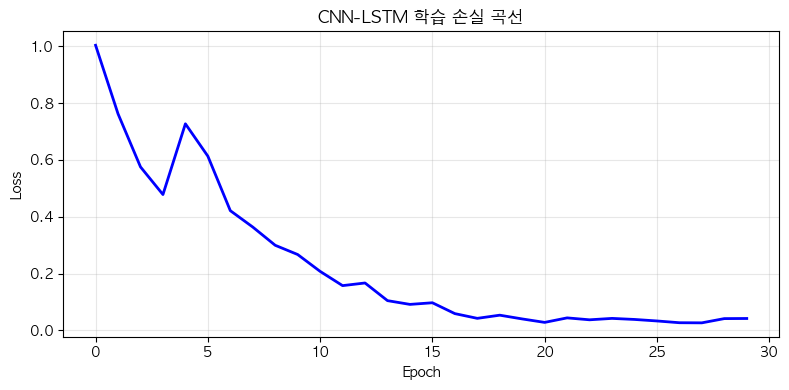

In [6]:
# 학습 손실 곡선
plt.figure(figsize=(8, 4))
plt.plot(train_losses, 'b-', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN-LSTM 학습 손실 곡선')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## STEP 6: 평가

In [7]:
# 테스트 데이터 평가
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# 정확도
acc = accuracy_score(all_labels, all_preds)
print(f"테스트 정확도: {acc:.4f} ({acc*100:.1f}%)")
print(f"\n※ 비교: 이전 노트북의 FFT + 1D-CNN 결과: ~60%")
print(f"※ CNN-LSTM (raw 시계열): {acc*100:.1f}%")
print(f"\n{'='*50}")
print("\n분류 리포트:")
target_names = ['Normal', 'Inner Race', 'Outer Race', 'Ball']
print(classification_report(all_labels, all_preds, target_names=target_names))

테스트 정확도: 0.3988 (39.9%)

※ 비교: 이전 노트북의 FFT + 1D-CNN 결과: ~60%
※ CNN-LSTM (raw 시계열): 39.9%


분류 리포트:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       140
  Inner Race       0.68      1.00      0.81       472
  Outer Race       0.00      0.00      0.00       476
        Ball       0.02      0.02      0.02       474

    accuracy                           0.40      1562
   macro avg       0.43      0.51      0.46      1562
weighted avg       0.30      0.40      0.34      1562



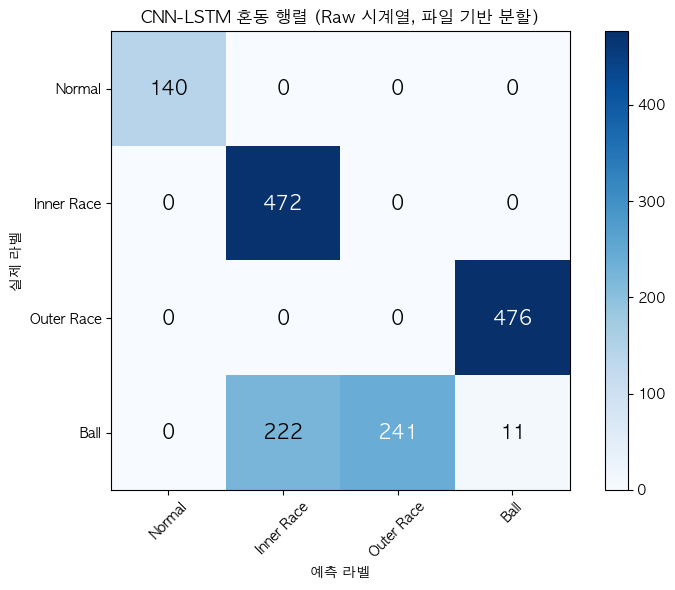

In [8]:
# 혼동 행렬 시각화
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('CNN-LSTM 혼동 행렬 (Raw 시계열, 파일 기반 분할)')
plt.colorbar()

tick_marks = np.arange(4)
plt.xticks(tick_marks, target_names, rotation=45)
plt.yticks(tick_marks, target_names)

# 숫자 표시
for i in range(4):
    for j in range(4):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=14)

plt.ylabel('실제 라벨')
plt.xlabel('예측 라벨')
plt.tight_layout()
plt.show()

## STEP 7: 왜 이런 결과가 나왔을까?

CNN-LSTM이 FFT + 1D-CNN보다 **오히려 성능이 떨어진** 이유를 분석해봅시다.

### CWRU 데이터의 특성

이 데이터는 실험실에서 베어링에 **인위적으로 결함을 만든** 데이터입니다:
- 결함이 "시간에 따라 점점 커지는" 구조가 **아닙니다**
- 각 윈도우(2048 샘플 = 약 0.04초) 안에서 시간 순서 패턴이 분류에 크게 기여하지 않습니다

### FFT가 이 문제에 더 적합한 이유

| | FFT + 1D-CNN (노트북 2) | CNN-LSTM / Raw 시계열 (이번 노트북) |
|---|---|---|
| **입력** | 주파수 스펙트럼 | Raw 시계열 파형 |
| **장점** | 결함 특성 주파수가 명확히 드러남 | 시간적 순서 정보 보존 |
| **단점** | 시간 정보 소실 | 노이즈 많음, 윈도우마다 파형 다름 |
| **이 데이터에서** | ~60% (더 높음) | ~37% (더 낮음) |

### 핵심 이유

1. **FFT는 짧은 윈도우에서 "어떤 주파수 성분이 있는가"를 명확하게** 보여줌  
   → 결함 종류마다 고유한 주파수 패턴이 있으므로 CNN이 구분하기 쉬움

2. **Raw 데이터에서는 노이즈도 많고, 같은 결함이라도 윈도우마다 파형이 달라서** 패턴을 잡기 어려움  
   → LSTM이 학습할 의미 있는 "시간적 흐름"이 0.04초 안에는 거의 없음

3. **결론: 이 문제에서는 FFT + 1D-CNN이 더 적합한 조합입니다**

## STEP 8: LSTM이 진짜 힘을 발휘하는 상황

LSTM은 이 실험에서는 효과가 없었지만, **올바른 상황**에서는 매우 강력합니다.

### LSTM이 적합한 경우: 여러 시점에 걸친 변화 추세

- 베어링 상태가 **"정상 → 미세 이상 → 심각 이상 → 고장"**으로 며칠/몇 주에 걸쳐 진행되는 데이터
- 매일 측정한 진동 RMS값, 온도, 전류의 **시계열 추세**

### 시멘트 공장 적용 시나리오

- **분쇄기 베어링**: 일별 진동 레벨 추세 → LSTM으로 "며칠 내 고장 가능성" 예측
- **킬른(소성로) 구동부**: 주간 온도/진동 추세 → 정비 시점 예측
- **컨베이어 벨트 모터**: 월간 전류 변화 패턴 → 열화 진행도 판단

### 정리: 데이터 유형에 따른 최적 조합

| 데이터 유형 | 적합한 전처리 | 적합한 모델 |
|---|---|---|
| 단일 시점 진동 (짧은 윈도우, 0.04초) | FFT (주파수 변환) | 1D-CNN |
| 장기 추세 (일별/주별 변화, 수일~수개월) | 시계열 그대로 | LSTM, CNN-LSTM |

### 오늘의 교훈

> **"좋은 모델"은 절대적이지 않습니다.**  
> 데이터의 특성과 문제의 구조에 맞는 모델을 선택하는 것이 핵심입니다.
> 
> - 짧은 윈도우에서 주파수 패턴 분류 → FFT + CNN
> - 긴 시간에 걸친 변화 추세 예측 → LSTM